## Week Ten - Assignment: Document Classification

Brandon Chung 4/19/2026

## Instructions

It can be useful to be able to classify new "test" documents using already classified "training" documents.  A common example is using a corpus of labeled spam and ham (non-spam) e-mails to predict whether or not a new document is spam.  Here is one example of such data:  UCI Machine Learning Repository: Spambase Data Set

For this project, you can either use the above dataset to predict the class of new documents (either withheld from the training dataset or from another source such as your own spam folder).

For more adventurous students, you are welcome (encouraged!) to come up a different set of documents (including scraped web pages!?) that have already been classified (e.g. tagged), then analyze these documents to predict how new documents should be classified.

For this assingment I will use the Spambase dataset sourced from the given UCI Machine Learning Repository of spam and ham (non-spam) emails to predict the classification of new unseen emails using a train/test split.

Spambase dataset found at: https://archive.ics.uci.edu/dataset/94/spambase

## Loading the Data

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier



column_names = [f"feature_{i}" for i in range(57)] + ["Target"]
df = pd.read_csv(r"C:\Users\chung\School\620 Web Analytics\spambase\spambase.data", header=None, names=column_names)

df.head()


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,Target
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [29]:
# Loading column names from the spambase.names file

columns = pd.read_csv(r"C:\Users\chung\School\620 Web Analytics\spambase\spambase.names", header=None, skiprows=33, nrows=57)
columns = columns[0].str.split(":").str[0].tolist()
df.columns = columns + ["Target"]
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Target
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

The data contains 4601 observations of 56 features and 1 target feature. The data contains no null values. 

Based on the documentation of the spambase dataset if target = 1 then the email is classified as spam, and if target = 0 then the email is classified as not spam

## Exploratory Analysis

Target
0    2788
1    1813
Name: count, dtype: int64


Text(0, 0.5, 'Count')

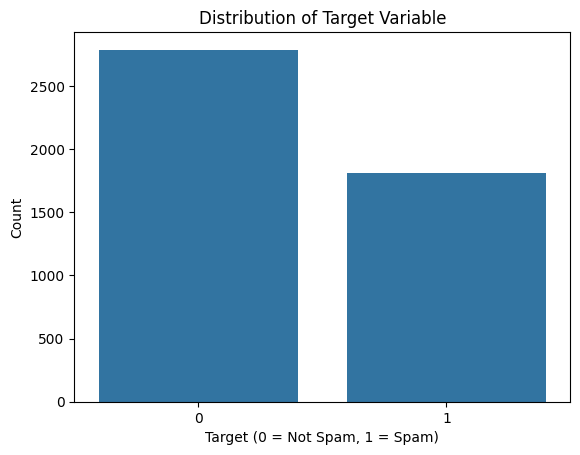

In [31]:
# Distribution of the target variable
print(df["Target"].value_counts())

# Visualize the distribution of the target variable

sns.countplot(x="Target", data=df)
plt.title("Distribution of Target Variable")
plt.xlabel("Target (0 = Not Spam, 1 = Spam)")
plt.ylabel("Count")

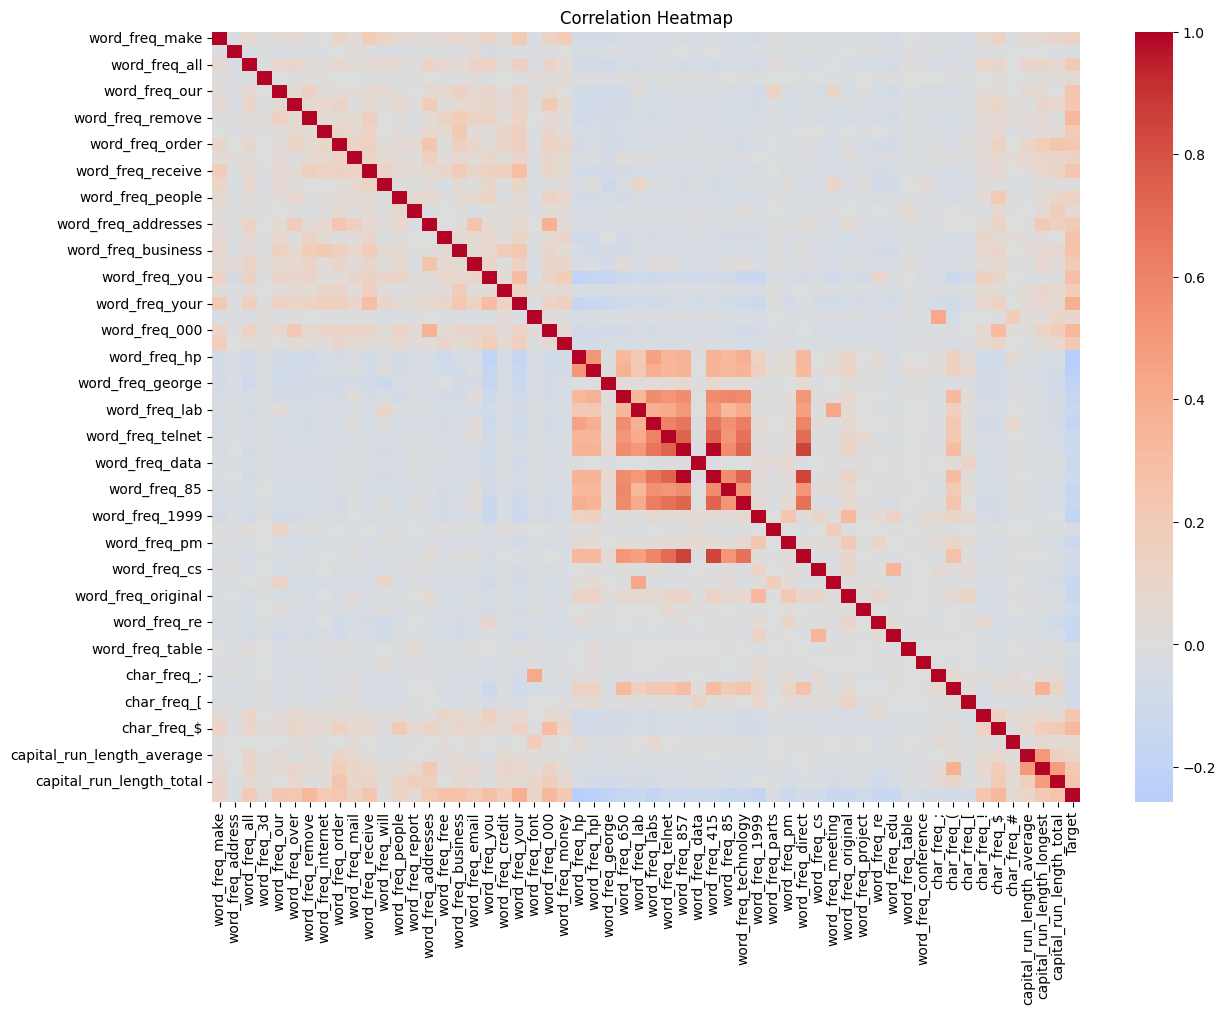

In [32]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


In [33]:
target_corr = df.corr()["Target"].sort_values(ascending=False)
target_corr.head(10)

Target                      1.000000
word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_$                 0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
capital_run_length_total    0.249164
word_freq_our               0.241920
Name: Target, dtype: float64

In [34]:
(df.groupby("Target").mean().T
 .assign(diff=lambda x: x[1] - x[0])
 .sort_values("diff", ascending=False)
 .head(10))


Target,0,1,diff
capital_run_length_total,161.470947,470.619415,309.148468
capital_run_length_longest,18.214491,104.393271,86.178780
capital_run_length_average,2.377301,9.519165,7.141864
word_freq_you,1.270341,2.264539,0.994199
word_freq_your,0.438702,1.380370,0.941668
word_freq_free,0.073587,0.518362,0.444775
char_freq_!,0.109984,0.513713,0.403729
word_freq_our,0.181040,0.513955,0.332915
word_freq_remove,0.009383,0.275405,0.266022
word_freq_000,0.007088,0.247055,0.239967


From the EDA the first thing to note is the use of capital letters that is apparent in spam emails. Our variables capital_run_length total, longest, and average all show significantly greater frequency in spam vs. non-spam emails, where the average total count of capital letters is double that than of non-spam emails. Certain high frequency words can also be indicative of spam such as you and your, where we see that the average counts are doubled in that of spam vs non-spam emails.  

## Modeling

In [35]:
# Creating train-test split

X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

In [36]:
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

preds = log_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 0.9196525515743756
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       531
           1       0.93      0.87      0.90       390

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



### Naive Bayes Classifier

In [37]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

nb_preds = nb.predict(X_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print(classification_report(y_test, nb_preds))


Naive Bayes Accuracy: 0.8219326818675353
              precision    recall  f1-score   support

           0       0.94      0.74      0.83       531
           1       0.72      0.94      0.82       390

    accuracy                           0.82       921
   macro avg       0.83      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921



### Random Forest Classifier 

In [38]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train) # Note: Random Forest can handle unscaled data, so we use X_train instead of X_train_scaled

rf_preds = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))


Random Forest Accuracy: 0.9576547231270358
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       531
           1       0.98      0.92      0.95       390

    accuracy                           0.96       921
   macro avg       0.96      0.95      0.96       921
weighted avg       0.96      0.96      0.96       921



## Conclusion and Results

In [40]:
importances = rf.feature_importances_

# Create a DataFrame for easy sorting and viewing
feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

# Sort by importance (descending)
feature_importance_df = feature_importance_df.sort_values(
    by="importance", ascending=False
)

feature_importance_df.head(10)


,feature,importance
51,char_freq_!,0.115729
52,char_freq_$,0.104606
6,word_freq_remove,0.074502
15,word_freq_free,0.062645
54,capital_run_length_average,0.061955
55,capital_run_length_longest,0.055173
20,word_freq_your,0.053303
56,capital_run_length_total,0.048684
24,word_freq_hp,0.044843
23,word_freq_money,0.032152


I ran logistic, naive bayes, and random forest models to find that our random forest model performs best in correctly classfying spam emails. Our random forest model provided an overall accuracy of 0.96, precision of 0.98, and recall of 0.92 on the held-out test set. These results indicate that when the random forest model classifies the email as spam, it is almost always correct, and that the model is able to mitigate false-positives the majority of the time.  

Based on the random forest model our most important features were the use of the characters ! and $, the words "remove" and "free", and also the frequency of the use of capitalized letters. This is in-line with what I had expected as important features, as spam emails would likely use incentives such as money, in addition to "attention grabbing" text such as capital letters or exclaimation points. 

Youtube link to video presentation: https://youtu.be/4HhtWPPPUBA